### Checking if log odds ratio distributions are better modeled as Gaussian or double Gaussian.

In [17]:
import os
import sys
import numpy as np
import pandas as pd
from scipy.stats import norm
from scipy.optimize import minimize
from tqdm.auto import tqdm
import seaborn as sns
import matplotlib.pyplot as plt

# Make src importable whether cwd is repo root or scripts/
cwd = os.getcwd()
if os.path.basename(cwd) == "scripts":
    repo_root = os.path.abspath(os.path.join(cwd, ".."))
else:
    repo_root = cwd

src_path = os.path.join(repo_root, "src")
if src_path not in sys.path:
    sys.path.insert(0, src_path)

print(f"Using src path: {src_path}")

# Import the module from src/
import odds_ratio_test as ort

# Define paths to data and results directories
# odds_ratio_results = os.path.join("..", "results/odds_ratio_test/")
odds_ratio_results = "~/kelvin-scratch/random_bootstrap_test/Results_Mar21/"

Using src path: /Users/calvin/orb-selection/src


Define functions

In [18]:
def gauss_fun(x,mu,sigma):
    """Gaussian function."""
    
    amp = np.power(2*np.pi*np.power(sigma,2),0.5)
    return np.exp(-np.power(x - mu, 2.) / (2 * np.power(sigma, 2.))) / amp

In [19]:
def gausslogl(x, mu, sigma):
    """Calculate the log-likelihood of a Gaussian distribution."""
    
    p = gauss_fun(x,mu,sigma)
    
    logL = np.nansum(np.log(p), axis = 0)
    
    return logL

In [20]:
def dgauss_fun(params,x):
    """Double Gaussian function."""
    
    mu1 = params[0]
    mu2 = params[1]
    sigma1 = params[2]
    sigma2 = params[3]
    w = params[4]
    
    gauss1 = gauss_fun(x,mu1,sigma1)
    gauss2 = gauss_fun(x,mu2,sigma2)
    
    p = w*gauss1 + (1-w)*gauss2
    
    return p

def dgausslogl(params,x):
    """Calculate the log-likelihood of a double Gaussian distribution."""

    p = dgauss_fun(params,x)
    
    logL = np.nansum(np.log(p), axis=0)
    
    return -logL

In [21]:
def tgauss_fun(params,x):
    """Triple Gaussian function."""
    
    w1 = params[0]
    mu1 = params[1]
    sigma1 = params[2]
    w2 = params[3]
    mu2 = params[4]
    sigma2 = params[5]
    mu3 = params[6]
    sigma3 = params[7]

    gauss1 = gauss_fun(x,mu1,sigma1)
    gauss2 = gauss_fun(x,mu2,sigma2)
    gauss3 = gauss_fun(x,mu3,sigma3)
    
    p = w1*gauss1 + w2*gauss2 + (1-w1-w2)*gauss3
    
    return p

def tgausslogl(params,x):
    """Calculate the log-likelihood of a triple Gaussian distribution."""

    p = tgauss_fun(params,x)
    
    logL = np.nansum(np.log(p), axis=0)
    
    return -logL

In [22]:
def qgauss_fun(params,x):
    """Quadruple Gaussian function."""
    
    w1 = params[0]
    mu1 = params[1]
    sigma1 = params[2]
    w2 = params[3]
    mu2 = params[4]
    sigma2 = params[5]
    w3 = params[6]
    mu3 = params[7]
    sigma3 = params[8]
    mu4 = params[9]
    sigma4 = params[10]

    gauss1 = gauss_fun(x,mu1,sigma1)
    gauss2 = gauss_fun(x,mu2,sigma2)
    gauss3 = gauss_fun(x,mu3,sigma3)
    gauss4 = gauss_fun(x,mu4,sigma4)

    p = w1*gauss1 + w2*gauss2 + w3*gauss3 + (1-w1-w2-w3)*gauss4
    
    return p

def qgausslogl(params,x):
    """Calculate the log-likelihood of a quadruple Gaussian distribution."""

    p = qgauss_fun(params,x)
    
    logL = np.nansum(np.log(p), axis=0)
    
    return -logL

In [ ]:
def param_optimization_new(data, params0_double, params0_triple, params0_quadruple, method='Nelder-Mead'):
    """Optimize parameters for Gaussian models."""
    
    mu = np.nanmean(data)
    sigma = np.nanstd(data)
    logL1 = gausslogl(data, mu, sigma)
    
    # Double Gaussian
    kwargs = {"fun": dgausslogl, "x0": params0_double, "args": data, "method": method}
    if method == 'COBYLA':
        kwargs["constraints"] = (
            {"type": "ineq", "fun": lambda p: p[4]},
            {"type": "ineq", "fun": lambda p: 1 - p[4]}
        )
    params_double = minimize(**kwargs).x
    logL2 = -dgausslogl(params_double, data)
    
    # Triple Gaussian
    kwargs = {"fun": tgausslogl, "x0": params0_triple, "args": data, "method": method}
    if method == 'COBYLA':
        kwargs["constraints"] = (
            {"type": "ineq", "fun": lambda p: p[0]},
            {"type": "ineq", "fun": lambda p: p[3]},
            {"type": "ineq", "fun": lambda p: 1 - p[0] - p[3]}
        )
    params_triple = minimize(**kwargs).x
    logL3 = -tgausslogl(params_triple, data)
    
    # Quadruple Gaussian
    kwargs = {"fun": qgausslogl, "x0": params0_quadruple, "args": data, "method": method}
    if method == 'COBYLA':
        kwargs["constraints"] = (
            {"type": "ineq", "fun": lambda p: p[0]},
            {"type": "ineq", "fun": lambda p: p[3]},
            {"type": "ineq", "fun": lambda p: p[6]},
            {"type": "ineq", "fun": lambda p: 1 - p[0] - p[3] - p[6]}
        )
    params_quadruple = minimize(**kwargs).x
    logL4 = -qgausslogl(params_quadruple, data)
    
    return ([mu, sigma], params_double, params_triple, params_quadruple), (logL1, logL2, logL3, logL4)

In [77]:
def param_optimization_old(data, params0_double, params0_triple, params0_quadruple):
    """Optimize parameters for Gaussian models.

    Args:
        data (array-like): Input data for model fitting.

    Returns:
        tuple: Optimized parameters for single and double Gaussian models, and their log-likelihoods.
    """

    mu = np.nanmean(data)
    sigma = np.nanstd(data)
    params_single = [mu, sigma]

    logL1 = gausslogl(data, mu, sigma)
    logL2 = np.zeros(np.shape(logL1))

    params_double = np.zeros(5)
    result = minimize(dgausslogl, params0_double, args=data, method='Nelder-Mead')
    params_double = result.x
    logL2 = -dgausslogl(params_double, data)

    params_triple = np.zeros(8)
    result = minimize(tgausslogl, params0_triple, args=data, method='Nelder-Mead')
    params_triple = result.x
    logL3 = -tgausslogl(data, params_triple)

    params_quadruple = np.zeros(11)
    result = minimize(qgausslogl, params0_quadruple, args=data, method='Nelder-Mead')
    params_quadruple = result.x
    logL4 = -qgausslogl(params_quadruple, data)

    params = [params_single, params_double, params_triple, params_quadruple]
    logLs = [logL1, logL2, logL3, logL4]

    return params, logLs

In [143]:
def bic_calc(n,k,logLs):
    """Calculate the Bayesian Information Criterion (BIC) for model comparison.

    Args:
        n (int): Number of data points.
        k (list): List containing the number of parameters for each model.
        logLs (list): List containing the log-likelihoods of each model.

    Returns:
        float: The difference in BIC between the two models.
    """

    BIC = np.zeros(len(k))
    for i in range(len(k)):
        BIC[i] = np.log(n)*k[i] - 2*logLs[i]

    # Here I find which model has the lowest BIC value, which indicates the best fit to the data. 
    delBIC2_1 = BIC[0] - BIC[1]
    delBIC3_1 = BIC[0] - BIC[2]
    delBIC3_2 = BIC[1] - BIC[2]
    delBIC4_1 = BIC[0] - BIC[3]
    delBIC4_2 = BIC[1] - BIC[3]
    delBIC4_3 = BIC[2] - BIC[3]
    
    print(f"Single vs Double BIC difference: {delBIC2_1}")
    print(f"Single vs Triple BIC difference: {delBIC3_1}")
    print(f"Double vs Triple BIC difference: {delBIC3_2}")
    print(f"Single vs Quadruple BIC difference: {delBIC4_1}")
    print(f"Double vs Quadruple BIC difference: {delBIC4_2}")
    print(f"Triple vs Quadruple BIC difference: {delBIC4_3}")

    print(f"BIC values: {BIC}")

    return BIC

In [25]:
def plot_it(data, params_double, params_triple=None, params_quadruple=None):
    fig, ax = plt.subplots(figsize=(8, 6))

    # Histogram of the true log odds ratios, filtered for occupancy
    sns.histplot(
        data,
        kde=False,
        bins=200,
        stat="density",
        ax=ax,
        legend=False,
        alpha=0.3,
    )

    x = np.linspace(data.min(), data.max(), 100)

    curve_specs = [
        ("Single Gaussian fit", "blue", norm.pdf(x, np.mean(data), np.std(data))),
        ("Double Gaussian fit", "red", dgauss_fun(params_double, x)),
    ]
    if params_triple is not None:
        curve_specs.append(("Triple Gaussian fit", "orange", tgauss_fun(params_triple, x)))
    if params_quadruple is not None:
        curve_specs.append(("Quadruple Gaussian fit", "green", qgauss_fun(params_quadruple, x)))

    for label, color, y in curve_specs:
        ax.plot(x, y, color=color, label=label)
        ax.fill_between(x, y, 0, color=color, alpha=0.2)

    ax.axvline(
        x=np.mean(data),
        linestyle="dotted",
        color="blue",
        label="Single Gaussian mean",
    )

    for i, mu in enumerate(params_double[:2]):
        ax.axvline(
            x=mu,
            linestyle="dotted",
            color="red",
            label="Double Gaussian means" if i == 0 else None,
        )

    if params_triple is not None:
        for i, mu in enumerate([params_triple[1], params_triple[4], params_triple[7]]):
            ax.axvline(
                x=mu,
                linestyle="dotted",
                color="orange",
                label="Triple Gaussian means" if i == 0 else None,
            )

    if params_quadruple is not None:
        for i, mu in enumerate([params_quadruple[1], params_quadruple[4], params_quadruple[7], params_quadruple[10]]):
            ax.axvline(
                x=mu,
                linestyle="dotted",
                color="green",
                label="Quadruple Gaussian means" if i == 0 else None,
            )

    ax.legend()

Import data

In [144]:
loss_results_all = pd.read_csv(
    str(odds_ratio_results) + "Run1_Loss_LT_50-95/loss_odds_results_all.csv"
)
dup_results_all = pd.read_csv(
    str(odds_ratio_results) + "Run2_Dup_RT_50-98/duplication_odds_results_all.csv"
)
total_occ_arr = loss_results_all["Occupancy"].values
loss_log_odds_ratios = loss_results_all["Log odds ratio"].values
dup_log_odds_ratios = dup_results_all["Log odds ratio"].values

Filter for occupancy thresholds

In [147]:
dup_49_98_lors = ort.occupancy_filter(
    dup_log_odds_ratios, 49, 98, total_occ_arr
)
loss_49_95_lors = ort.occupancy_filter(
    loss_log_odds_ratios, 49, 95, total_occ_arr
)

## New version

In [148]:
data_loss = loss_49_95_lors
mu = np.nanmean(data_loss)
sigma = np.nanstd(data_loss)
params0_double = [mu - sigma, mu + sigma, sigma, sigma, 0.4]
params0_triple = [0.33, mu - sigma, sigma, 0.33, mu, sigma, mu + sigma, sigma]
# params0_quadruple = [0.5, -1.5, sigma, 0.2, 0, sigma/2, 0.25, 1, sigma, 1.1, sigma]
params0_quadruple = [0.25, -1.5*mu, sigma, 0.25, -0.5*mu, sigma, 0.25, 0.5*mu, sigma, 1.5*mu, sigma]

params_loss_new, logLs_loss = param_optimization_new(
    data_loss, params0_double, params0_triple, params0_quadruple, method='COBYLA'
    )

bic_loss = bic_calc(len(data_loss), [2,5,8,11], logLs_loss)

/var/folders/bh/l9d0n24d5011lh6bfqzp4n7r0000gn/T/ipykernel_69155/2482134823.py:22: RuntimeWarning: invalid value encountered in log
  logL = np.nansum(np.log(p), axis=0)
/var/folders/bh/l9d0n24d5011lh6bfqzp4n7r0000gn/T/ipykernel_69155/3093678587.py:26: RuntimeWarning: invalid value encountered in log
  logL = np.nansum(np.log(p), axis=0)


Single vs Double BIC difference: 13.622686271894054
Single vs Triple BIC difference: 17.14022714330349
Double vs Triple BIC difference: 3.5175408714094374
Single vs Quadruple BIC difference: -42.86474102155262
Double vs Quadruple BIC difference: -56.48742729344667
Triple vs Quadruple BIC difference: -60.00496816485611
BIC values: [19877.30433318 19863.6816469  19860.16410603 19920.1690742 ]


/var/folders/bh/l9d0n24d5011lh6bfqzp4n7r0000gn/T/ipykernel_69155/526508026.py:30: RuntimeWarning: invalid value encountered in log
  logL = np.nansum(np.log(p), axis=0)


In [138]:
params_loss_new[2]

array([ 0.25652609, -2.19754721,  0.98804531,  0.44572094, -0.45436279,
        0.92783556,  0.40029586,  1.57729522])

In [139]:
bic_loss

array([19877.30433318, 19863.6816469 , 19860.16410603, 19920.1690742 ])

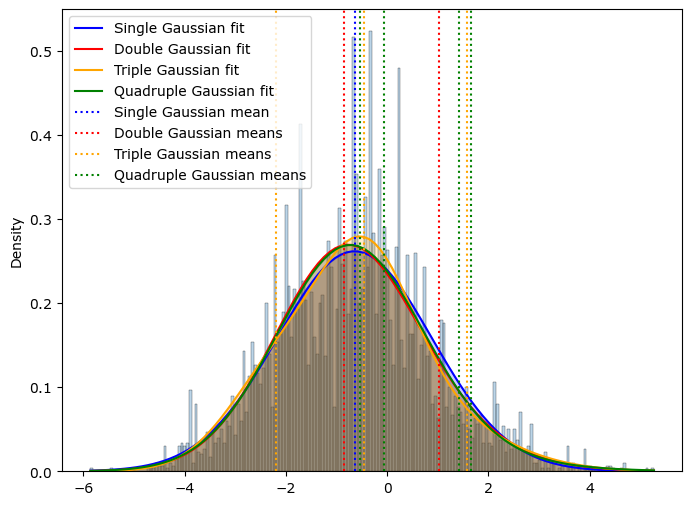

In [149]:
plot_it(data_loss, *params_loss_new[1:4])

Check whether duplication distribution is bimodal, trimodal, quadmodal

In [150]:
data_dup = dup_49_98_lors
mu = np.nanmean(data_dup)
sigma = np.nanstd(data_dup)
params0_double = [mu - sigma, mu + sigma, sigma, sigma, 0.5]
# params0_triple = [0.3, mu - sigma, sigma/2, 0.4, mu, sigma/2, mu + sigma, sigma/2]
params0_triple = [0.33, mu - sigma, sigma, 0.33, mu, sigma, mu + sigma, sigma]


# params0_quadruple = [0.4, -0.1, sigma/2, 0.5, 0.1, sigma, 0.05, 0.3, sigma, 0.4, sigma]
params0_quadruple = [0.25, -1.5*mu, sigma, 0.25, -0.5*mu, sigma, 0.25, 0.5*mu, sigma, 1.5*mu, sigma]

params_dup, logLs_dup = param_optimization_new(
    data_dup, params0_double, params0_triple, params0_quadruple, method='COBYLA'
    )

bic_dup = bic_calc(len(data_dup), [2,5,8,11], logLs_dup)

/var/folders/bh/l9d0n24d5011lh6bfqzp4n7r0000gn/T/ipykernel_69155/2482134823.py:22: RuntimeWarning: invalid value encountered in log
  logL = np.nansum(np.log(p), axis=0)
/var/folders/bh/l9d0n24d5011lh6bfqzp4n7r0000gn/T/ipykernel_69155/3093678587.py:26: RuntimeWarning: invalid value encountered in log
  logL = np.nansum(np.log(p), axis=0)


Single vs Double BIC difference: 58.759970230014005
Single vs Triple BIC difference: 128.22710288389862
Double vs Triple BIC difference: 69.46713265388462
Single vs Quadruple BIC difference: 103.6703514437504
Double vs Quadruple BIC difference: 44.9103812137364
Triple vs Quadruple BIC difference: -24.55675144014822
BIC values: [22142.0904957  22083.33052547 22013.86339281 22038.42014425]


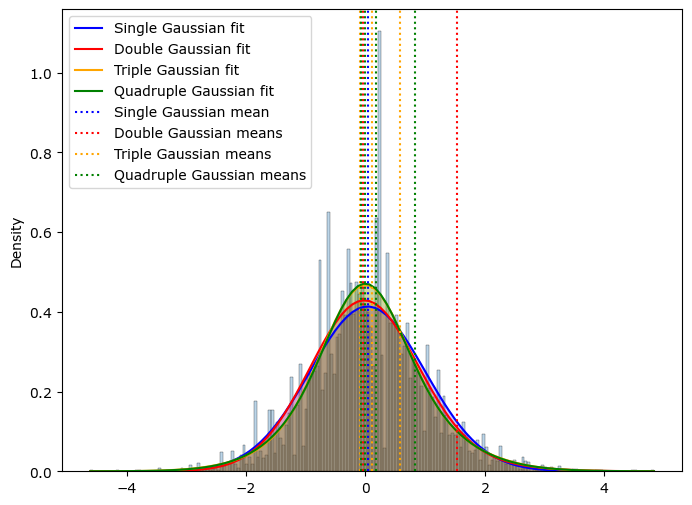

In [151]:
plot_it(data_dup, *params_dup[1:4])